# Issue 196 - how to optimize an aspheric singlet

In [1]:
%matplotlib widget

In [2]:
isdark = True

In [3]:
from rayoptics.environment import *
from scipy.optimize import least_squares

In [4]:
def define_optics(n):
    opm = OpticalModel()
    sm  = opm.seq_model
    osp = opm.optical_spec
    pm = opm.parax_model
    
    osp['fov'] = FieldSpec(osp, key=['object', 'angle'], value=0.0, flds=[0.], is_relative=True) 
    osp['wvls'].wavelengths = [850.0]
    
    opm.radius_mode = True
    #### parameters
    # NA lens
    NA = 0.2 
    # Diameter
    D = 10
    # focal
    f = (D/2-0.6875)/NA
    # curvature radius
    R = (n-1)*f 
    # min thickness lenses
    t = R-(R**2-(D/2)**2)**(1/2) 
    # shift principal plan
    spp = -t*f/R*(n-1)/n
    
    ## Value of the pupil set for 1 fiber output
    osp['pupil'] = PupilSpec(osp, key=['object', 'epd'], value=(f+spp)*NA*2)
    # add this to not override entered semi-diameters.
    sm.do_apertures = False
    
    # waveguide interface
    # sm.gaps[0].thi=f+spp
    sm.gaps[0].thi=1e13
    # pupil (to control pupil diameter)
    opm.add_dummy_plane(sd=(f+spp)*NA)
    sm.set_stop()
    # lens
    sm.add_surface([R,t,n],sd=D/2-1e-5)
    sm.add_surface([0,f+spp],sd=D/2-1e-5)
    
    opm.update_model()
    
    return opm, sm, osp, pm

In [5]:
def optimize(order: int):
    # solve for aspheric coefficients to minimize ray fan errors
    initial_guess = [0] * order
    
    from functools import partial
    objective_waddparam = partial(evaluate_model, opm=opm, sm=sm)
    # Optimisation
    result = least_squares(objective_waddparam, initial_guess, method='lm', xtol=1e-14, gtol=1e-12)
    # set opm to the solution
    evaluate_model(result.x, opm, sm)
    print("Best coefficients :", result.x)
    return result

In [6]:
def ssq_function(opm):
    # get the aberration levels
    ray_fan = RayFanFigure(opt_model=opm, data_type='Ray')
    ray_fan.update_data()
    y_values = ray_fan.axis_data_array[0][0][1][0]
    
    return y_values

In [7]:
def evaluate_model(coeffs, opm, sm):
    # change profile with coefficients
    coeffs = np.concatenate((np.array([0.]), coeffs));
    s2 = sm.ifcs[2]
    s2.profile = EvenPolynomial(r=s2.profile.r,cc=0,coefs=coeffs)
    opm.update_model()
    abr_vec = ssq_function(opm)
    return abr_vec

In [8]:
def sumsq(y_values):
    return np.sum(np.square(y_values))

## 6th order asphere

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


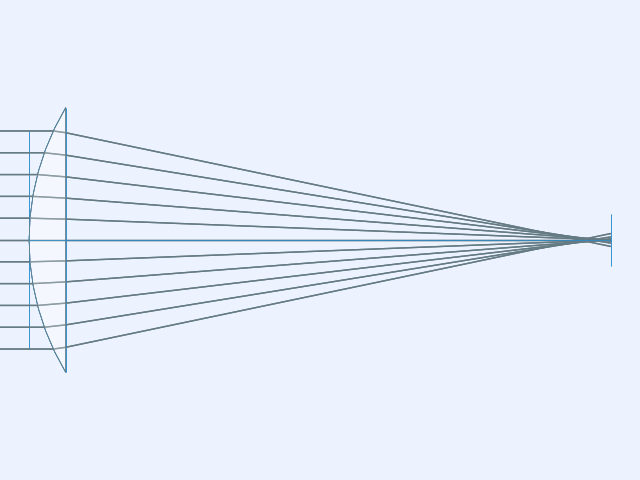

In [9]:
n = 1.4512 # Silica
opm, sm, osp, pm = define_optics(n)

layout_plt = plt.figure(FigureClass=InteractiveLayout, opt_model=opm,
                        do_draw_ray_fans=True,
                        # clip_rays=True, 
                        do_draw_beams=False, 
                        do_draw_edge_rays=False,
                        do_paraxial_layout=False).plot()

In [10]:
result2 = optimize(2)

Best coefficients : [-7.67791496e-05 -7.88026088e-07]


In [11]:
result2

     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [ 4.620e-04  2.365e-04 ... -2.365e-04 -4.620e-04]
           x: [-7.678e-05 -7.880e-07]
        cost: 1.1335169965141006e-06
         jac: [[ 2.531e+03  6.483e+04]
               [ 2.388e+03  5.872e+04]
               ...
               [-2.388e+03 -5.872e+04]
               [-2.531e+03 -6.483e+04]]
        grad: [-5.781e-09 -1.163e-07]
  optimality: 1.1632370405642239e-07
 active_mask: [0 0]
        nfev: 4
        njev: None

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


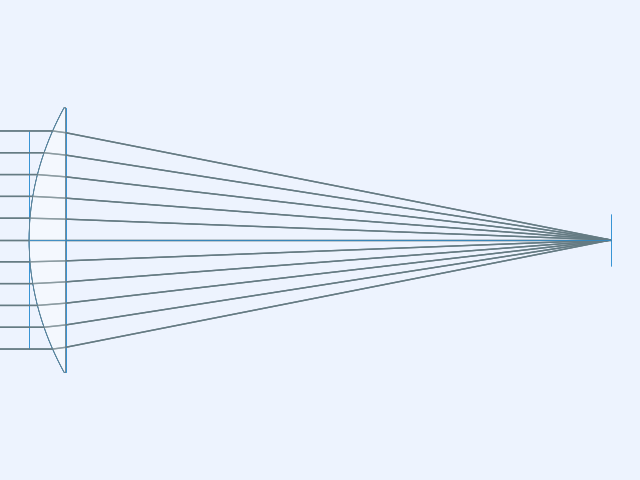

In [12]:
layout_plt2 = plt.figure(FigureClass=InteractiveLayout, opt_model=opm,
                        do_draw_ray_fans=True,
                        # clip_rays=True, 
                        do_draw_beams=False, 
                        do_draw_edge_rays=False,
                        do_paraxial_layout=False).plot()

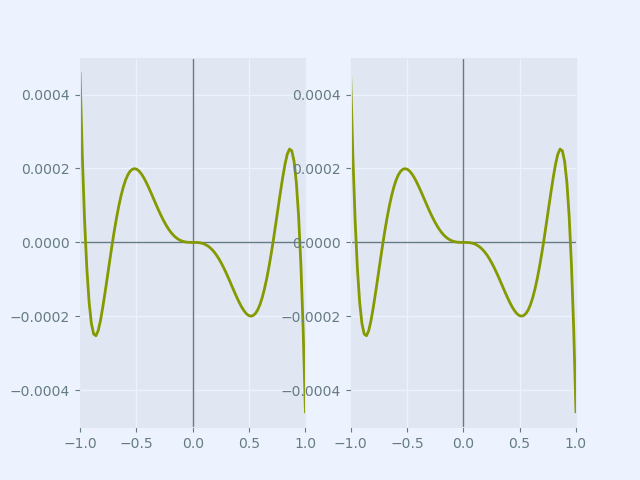

In [13]:
abr_plt2 = plt.figure(FigureClass=RayFanFigure, opt_model=opm, data_type='Ray', scale_type=Fit.User_Scale, user_scale_value=.0005).plot()

## 8th order asphere

In [14]:
n = 1.4512 # Silica
opm, sm, osp, pm = define_optics(n)

In [15]:
result3 = optimize(3)

Best coefficients : [-7.84592201e-05 -5.84025066e-07 -6.39739054e-09]


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


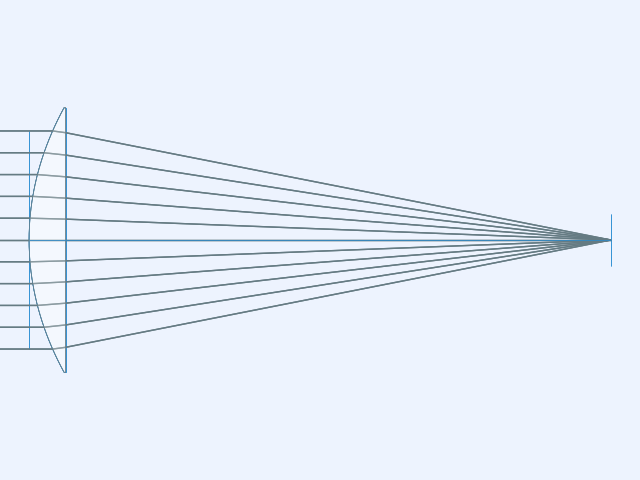

In [16]:
layout_plt3 = plt.figure(FigureClass=InteractiveLayout, opt_model=opm,
                        do_draw_ray_fans=True,
                        # clip_rays=True, 
                        do_draw_beams=False, 
                        do_draw_edge_rays=False,
                        do_paraxial_layout=False).plot()

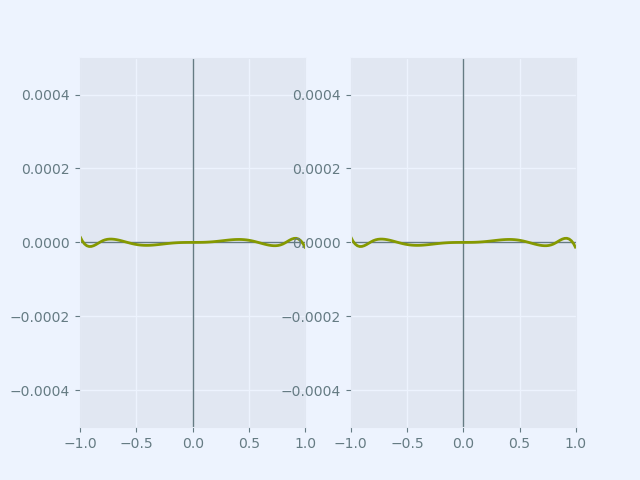

In [17]:
abr_plt3 = plt.figure(FigureClass=RayFanFigure, opt_model=opm, data_type='Ray', scale_type=Fit.User_Scale, user_scale_value=.0005).plot()

## 10th order asphere

In [18]:
n = 1.4512 # Silica
opm, sm, osp, pm = define_optics(n)

In [19]:
result4 = optimize(4)

Best coefficients : [-7.83152417e-05 -6.15093063e-07 -4.14659413e-09 -5.36426101e-11]


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


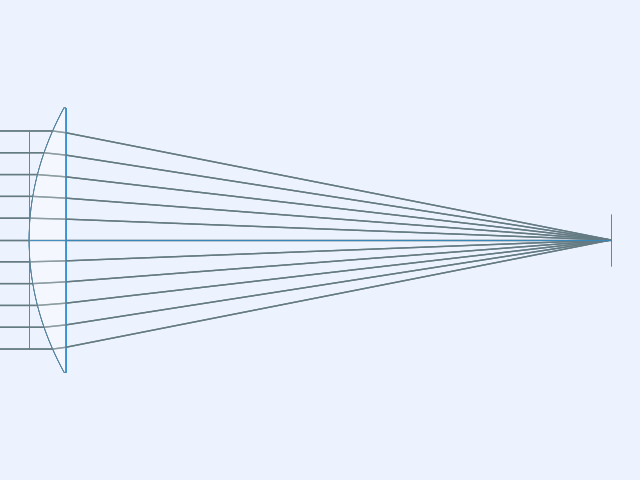

In [20]:
layout_plt4 = plt.figure(FigureClass=InteractiveLayout, opt_model=opm,
                        do_draw_ray_fans=True,
                        # clip_rays=True, 
                        do_draw_beams=False, 
                        do_draw_edge_rays=False,
                        do_paraxial_layout=False).plot()

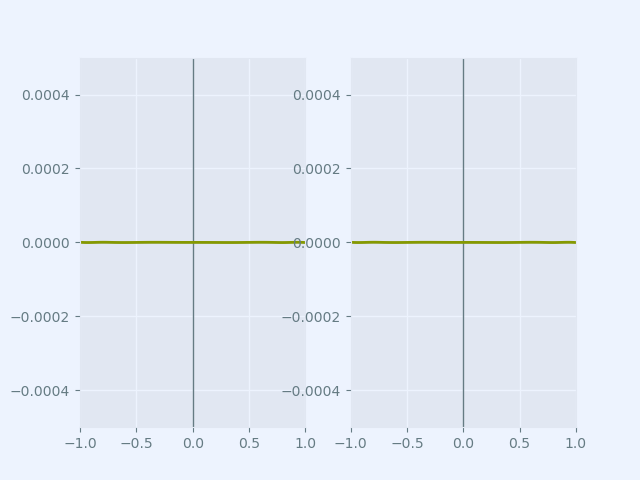

In [21]:
abr_plt4 = plt.figure(FigureClass=RayFanFigure, opt_model=opm, data_type='Ray', scale_type=Fit.User_Scale, user_scale_value=.0005).plot()

In [22]:
result2.x, result3.x, result4.x

(array([-7.67791496e-05, -7.88026088e-07]),
 array([-7.84592201e-05, -5.84025066e-07, -6.39739054e-09]),
 array([-7.83152417e-05, -6.15093063e-07, -4.14659413e-09, -5.36426101e-11]))